**Caso de Estudio**

Una entidad del sector FINTECH, está interesada en implementar un sistema para la gestion prospectiva de riesgos basada en potenciales de captura de Gases de Efecto Invernadero (GEI) asociados a las fallas tecnologicas en sus canales electronicos.

Para la gestion de los riesgos, los impactos mas frecuentes estan asociados con las transacciones fallidas en los canales electronicos, es por esto que la entidad quiere disenar una serie de matrices de gestion e impacto que le permitan mitigar los riesgos asociados.

Para la construccion de estas matrices se procedera con la clusterizacion de las variables de Frecuencia (Numero de transacciones fallidas) e Impacto (Valor Generado Promedio en Millones USD) utilizando el metodo K-means.

**Marco conceptual**: el modelo se basa en la Distribucion Agregada de Perdidas (LDA - Loss Distribution Approach) de Basilea II/III para riesgo operacional, donde las perdidas se segmentan en tres categorias:
*   C1: Perdidas Esperadas (cubiertas con provisiones)
*   C2: Perdidas no Esperadas (cubiertas con capital economico)
*   C3: Perdidas Catastroficas (umbral OpVaR 99.9%)

0. Se procede con la carga de las librerias de trabajo

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


0. Creamos la funcion de clusterizacion para poderla reutilizar varias veces

In [2]:
def clusterizacion(Xi):
  #Proceso de Clusterizacion
  XC= np.random.choice(Xi,size=5)
  XC= np.sort(XC) #Semillas de la clusterizacion se deben llamar: (Improbable, Posible, Ocacional, Probable y Frecuente)
  nc= np.zeros((len(Xi),1)) #Aqui clasifico los datos en cada una de las semillas

  for k in range(len(Xi)):
   d=np.abs(XC-Xi[k]) #Distancia de cada dato a una semilla
   nc[k]=np.argmin(d)
   nc2= np.int32(nc[k]) #Numero de pertenencia al cluster en enteros
   XC[nc2,]=(XC[nc2]+Xi[k])/2 #Actualizamos la semilla a la que pertenece cada dato (K-Medoids)

  return XC,nc #Me va a retornar clusters y cluster al que pertenece el dato

1. Se cargan los archivos de trabajo

In [3]:
nxl ='/content/drive/MyDrive/Integracion de datos y prospectiva/5. Riesgo Operacional FallasTecnológicas.xlsx'
XDB = pd.read_excel(nxl, sheet_name='Fallas Tecnológicas', header=1)
XDB = XDB.dropna()
XDB.head()

#Obtenemos la variable de frecuencia
Xf=np.array(XDB['Transacciones Fallidas'], dtype=float)
XCf,ncf=clusterizacion(Xf)

#Obtenemos los clustes para la severidad
Xs=np.array(XDB['Valor Generado Promedio (Millones)'], dtype=float)
XCs,ncs=clusterizacion(Xs)

#Se procede a determinar la distribucion de las perdidas
LDA= Xf*Xs
XClda,nclda=clusterizacion(LDA)

#Mapeamos la columna Descripcion Evento a un nivel de riesgo (1 a 5)
mapa_riesgo={
    'Errores visuales menores, problemas de usabilidad, notificaciones falsas, interrupciones breves de servicios no críticos.':1,
    'Errores en la interfaz de usuario, fallas en funcionalidades secundarias, problemas de rendimiento menores, incidentes de seguridad menores, interrupciones breves de servicios no críticos.':2,
    'Degradación del rendimiento por varias horas, interrupción temporal de servicios clave, pérdida de datos parcial, incidentes de seguridad que afectan a un número considerable de clientes, errores en la interfaz de usuario que impiden realizar transacciones.':3,
    'Degradación severa del rendimiento por más de 12 horas, interrupción prolongada de servicios clave como transferencias, pérdida parcial de datos críticos, vulnerabilidades de seguridad explotadas a gran escala.':4,
    'Caída total del sistema por más de 24 horas, pérdida masiva de datos de clientes, ciberataque que compromete la integridad de la plataforma, desastre natural que afecta la infraestructura principal.':5
}
Riesgos=XDB['Descripción Evento'].map(mapa_riesgo).fillna(1).values

#Creamos un dataframe de descarga
df=pd.DataFrame(np.column_stack((Xf,ncf,Xs,ncs,LDA,nclda,Riesgos)))
df.columns=['Freq','Nivel_f','Sev.','Nivel_S','LDA','Nivel_LDA','Riesgos']
df.to_excel('MatrizRiesgo.xlsx')
df.head()

,Freq,Nivel_f,Sev.,Nivel_S,LDA,Nivel_LDA,Riesgos
0,1.0,0.0,0.5374,1.0,0.5374,0.0,1.0
1,4.0,1.0,1.1978,1.0,4.7912,2.0,2.0
2,5.0,1.0,0.4269,0.0,2.1345,1.0,1.0
3,6.0,1.0,1.0814,1.0,6.4884,2.0,2.0
4,7.0,2.0,1.2105,1.0,8.4735,2.0,2.0


2. Procedemos con la construccion de la matriz de eventos de riesgo

[[152.  89.  45.  15.   3.]
 [391. 223. 129.  33.  24.]
 [401. 351. 107.  62.  26.]
 [452. 328. 134.  44.  61.]
 [127.  59.  54.  22.   0.]]


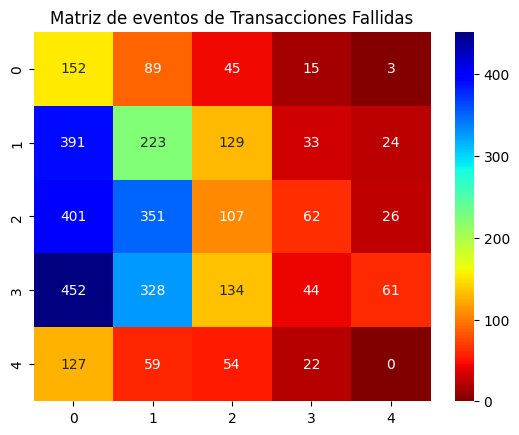

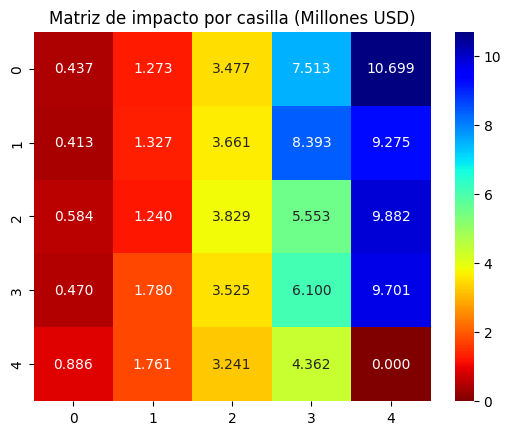

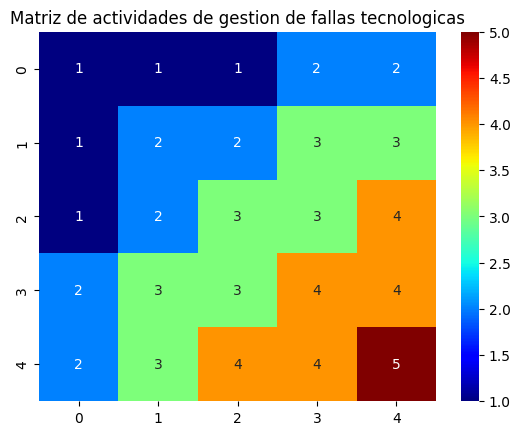

In [4]:
MEf=np.zeros((5,5)) #Cuantas transacciones fallidas se presentaron por categoria frecuencia, impacto.
MEs=np.zeros((5,5)) #Matriz Severidad por transaccion fallida

for k in range(len(Xf)):
    nf=np.int32(df.iloc[k,1])
    nc=np.int32(df.iloc[k,3])
    MEf[nf,nc]=MEf[nf,nc]+Xf[k,]
    MEs[nf,nc]=(MEs[nf,nc]+Xs[k,])/2

print(MEf)

plt.figure()
sns.heatmap(MEf,annot=True,fmt='.0f',cmap='jet_r')
plt.title("Matriz de eventos de Transacciones Fallidas")
plt.show()

#Cuanto cuesta cada transaccion fallida en cada casilla
plt.figure()
sns.heatmap(MEs,annot=True,fmt='.3f',cmap='jet_r')
plt.title("Matriz de impacto por casilla (Millones USD)")
plt.show()

#Procederemos con la creacion de la matriz de impacto
#Esta matriz me determina igualmente las actividades de gestion ( 5: indica revisar 5 veces a la semana esos eventos)
MI=np.array ([[1,1,1,2,2],
             [1,2,2,3,3],
             [1,2,3,3,4],
             [2,3,3,4,4],
             [2,3,4,4,5]])

plt.figure()
sns.heatmap(MI,annot=True,fmt='.0f',cmap='jet')
plt.title("Matriz de actividades de gestion de fallas tecnologicas")
plt.show()

Ingresar el nivel de Gestion(1,2,3,4,5):3


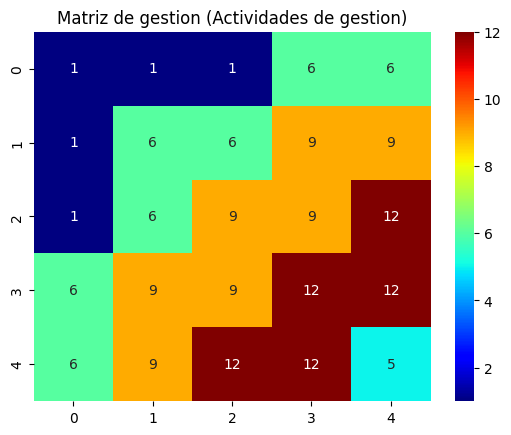

In [5]:
#Matriz de Gestion
nivel_gestion_str = input("Ingresar el nivel de Gestion(1,2,3,4,5):")
nivel_gestion_int = int(nivel_gestion_str) # Convert input to integer

# Initialize MG from MI
MG = np.copy(MI)

# Apply conditional multiplication: MG = nivel_gestion_int * MG when MG is > 1 and < 5
condition = (MG > 1) & (MG < 5)
MG[condition] = nivel_gestion_int * MG[condition]

plt.figure()
sns.heatmap(MG,annot=True,fmt='.0f',cmap='jet') # Plot the modified MG
plt.title("Matriz de gestion (Actividades de gestion)")
plt.show()

3. Se procede con la estimacion de las metricas estadisticas asociadas a las matrices de frecuencia e impacto(Severidad)

In [6]:
ps=np.mean(MEs)
print("El promedio de impacto por atender una falla tecnologica es:",ps)

#2. Como no todas las fallas tienen la misma frecuencia lo que quiere decir que hay pocas fallas que sufren perdidas extremas.
pp=np.sum(MEf*MEs)/np.sum(MEf)
print("El promedio ponderaro de la severidad por atender una falla tecnologica es:",pp)
#3. Se procede a determinar la perdida ponderada teniendo igualmente la matriz de impacto - Nivel de riesgo

pnr=np.sum(MEf*MI*MEs)/np.sum(MEf*MI)
print("La perdida ponderada por atender una falla tecnologica es:",pnr)

#4. Se procede a determinar la perdida ponderada teniendo igualmente la matriz de Gestion
png=np.sum(MEf*MI*MEs)/np.sum(MEf*MG)
print(f"La perdida ponderada por atender una falla teniendo en cuenta la gestion un nivel de gestion {nivel_gestion_int} es: {png}")

El promedio de impacto por atender una falla tecnologica es: 3.9753003467182277
El promedio ponderaro de la severidad por atender una falla tecnologica es: 1.8628367253030194
La perdida ponderada por atender una falla tecnologica es: 2.5006407537345994
La perdida ponderada por atender una falla teniendo en cuenta la gestion un nivel de gestion 3 es: 0.9329180627839282


**Analisis de Resultados**

1. **Promedio simple (`ps`) vs Promedio ponderado (`pp`)**: el `pp` es menor que `ps`, lo que confirma que la distribucion de perdidas tiene cola larga. La FINTECH presenta muchos eventos de baja severidad y pocos eventos de alta severidad, comportamiento tipico del riesgo operacional.

**Matriz de impacto**:
Esta matriz nos indica el nivel de impacto que tiene un grupo de fallas tecnologicas dentro de la matriz de eventos de riesgo sobre las finanzas de la entidad FINTECH. La perdida ponderada con matriz de impacto (`pnr`) crece respecto al `pp` porque amplifica las celdas de mayor frecuencia y severidad.

**Matriz de Gestion**: Esta matriz indica la atencion que se le tiene que poner a un nivel de impacto (1: Capacitacion basica, 5: Plan de recuperacion de desastres + ciberseguro). La perdida ponderada con gestion (`png`) disminuye respecto a `pnr`, evidenciando el efecto mitigador de las actividades de gestion. Esta diferencia (`pnr - png`) es la base del Valor Capturado Financiero.

In [11]:
fila = np.int32(input("ingresar nivel de frecuencia:"))
col= np.int32(input("Ingresar el Nivel para la Severidad:"))
df[(df.iloc[:,1]==fila)&(df.iloc[:,3]==col)]

ingresar nivel de frecuencia:2
Ingresar el Nivel para la Severidad:2


,Freq,Nivel_f,Sev.,Nivel_S,LDA,Nivel_LDA,Riesgos,Nivel de Gestion,LDA_Gestionada
19,7.0,2.0,2.7284,2.0,19.0988,3.0,3.0,6.0,9.54940
157,6.0,2.0,2.6077,2.0,15.6462,3.0,3.0,6.0,7.82310
164,7.0,2.0,3.8337,2.0,26.8359,3.0,3.0,6.0,13.41795
248,5.0,2.0,3.7633,2.0,18.8165,2.0,3.0,4.0,9.40825
273,5.0,2.0,2.7295,2.0,13.6475,2.0,3.0,4.0,6.82375
282,6.0,2.0,3.6744,2.0,22.0464,3.0,3.0,6.0,11.02320
388,7.0,2.0,3.5891,2.0,25.1237,3.0,3.0,6.0,12.56185
398,6.0,2.0,3.0696,2.0,18.4176,2.0,3.0,4.0,9.20880
420,6.0,2.0,3.0000,2.0,18.0000,2.0,3.0,4.0,9.00000
451,7.0,2.0,3.9513,2.0,27.6591,3.0,3.0,6.0,13.82955


##**Caso de Estudio 2**
Se procedera con la caracterizacion de la distribucion agregada de las perdidas (LDA: Loss Distribution Approach) y sus parametros de riesgo.
*   C1: Perdidas Esperadas (Errores visuales menores, fallas de UI - se cubren con provisiones)
*   C2: Perdidas no esperadas (Perdidas Gestionables: Degradaciones, interrupciones temporales - se cubren con capital economico)
*   C3: Perdidas Catastroficas (Caida total del sistema, ciberataques masivos - umbral OpVaR 99.9% de Basilea)

In [8]:
#Se cargan los costos de las actividades de gestion (Hoja 'Gestión' del Excel)
XGes = pd.read_excel(nxl, sheet_name='Gestión', header=1)
XGes = XGes.rename(columns={'Unnamed: 0':'Nivel'})
XGes[['Nivel','Nivel de Gestión','Costo (KUSD)','Desviación']]

,Nivel,Nivel de Gestión,Costo (KUSD),Desviación
0,1,Bajo,0.012171,0.005710
1,2,Medio,0.037437,0.027454
2,3,Moderado,0.173067,0.085586
3,4,Alto,0.407991,0.038555
4,5,Crítico,0.628350,0.076041


El limite de las perdidas esperadas (C1 es): 9.45111269614836
El limite inferior de las perdidas  (C3 es): 102.9021000000008
El numero de transacciones fallidas con perdidas menores a C1 son: 1952.0
El numero de transacciones fallidas con perdidas mayores al OPVar son: 10.0
El numero de transacciones fallidas con perdidas gestionables (C2) son: 1370.0
El porcentaje de eventos de riesgo C1 es: 0.5858343337334934
El porcentaje de eventos de riesgo C2 es: 0.41116446578631455
El porcentaje de eventos de riesgo C3 es: 0.003001200480192077
Me puedes ingresar el nivel de gestion de gestion [1,2,3,4]:1
El numero de transacciones fallidas en C1 luego de una gestion 1 es: 1952.0
El numero de transacciones fallidas en C3 luego de una gestion 1 es: 10.0
El numero de transacciones fallidas en C2 luego de una gestion 1 es: 1370.0
El numero de transacciones que migran de C2-C1 son: 0.0
La perdida promedio es: 9.45111269614836
El costo de gestion es: 0.012170914647370606
El valor capturado financiero 

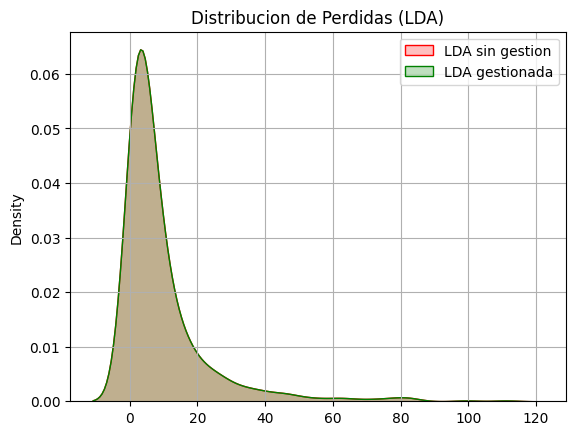

In [14]:
#Se procede con la grafica de la distribucion de perdidas (LDA)
LDA= np.array(df.iloc[:,4])
LC1=np.mean(LDA);print("El limite de las perdidas esperadas (C1 es):",LC1)
OPVar=np.percentile(LDA,99.9);print("El limite inferior de las perdidas  (C3 es):",OPVar)

#Contabilizamos el numero de eventos por categoria de riesgo
nc_c1=np.sum(df[df.iloc[:,4]<LC1].iloc[:,0])
print("El numero de transacciones fallidas con perdidas menores a C1 son:",nc_c1)
nc_c3=np.sum(df[df.iloc[:,4]>OPVar].iloc[:,0])
print("El numero de transacciones fallidas con perdidas mayores al OPVar son:",nc_c3)
nc_c2=np.sum(df.iloc[:,0])-nc_c1-nc_c3
print("El numero de transacciones fallidas con perdidas gestionables (C2) son:",nc_c2)

#Los valores porcentuales del riesgo son:
print("El porcentaje de eventos de riesgo C1 es:",nc_c1/np.sum(df.iloc[:,0]))
print("El porcentaje de eventos de riesgo C2 es:",nc_c2/np.sum(df.iloc[:,0]))
print("El porcentaje de eventos de riesgo C3 es:",nc_c3/np.sum(df.iloc[:,0]))

#Gestion de Riesgos - Captura GEI (Gases Efecto Invernadero)
nimp=np.array(df.iloc[:,5]+1)
ngest=np.int32(input("Me puedes ingresar el nivel de gestion de gestion [1,2,3,4]:"))
ng2=nimp*ngest
df['Nivel_LDA']=nimp
df['Nivel de Gestion']=ng2

#Se procede a determinar la distribucion de perdidas gestionadas
LDA_G=LDA*(nimp/ng2)
df['LDA_Gestionada']=LDA_G

#Procedemos a contar las transacciones fallidas luego de la gestion
nc_c1_g=np.sum(df[LDA_G<LC1].iloc[:,0])
print(f"El numero de transacciones fallidas en C1 luego de una gestion {ngest} es: {nc_c1_g}")
nc_c3_g=np.sum(df[LDA_G>OPVar].iloc[:,0])
print(f"El numero de transacciones fallidas en C3 luego de una gestion {ngest} es: {nc_c3_g}")
nc_c2_g=np.sum(df.iloc[:,0])-nc_c1_g-nc_c3_g
print(f"El numero de transacciones fallidas en C2 luego de una gestion {ngest} es: {nc_c2_g}")

#Valor capturado financiero
ncg=nc_c1_g-nc_c1
print("El numero de transacciones que migran de C2-C1 son:",ncg)
PProm= np.mean(LDA) #Perdida promedio por transaccion fallida (Millones USD)
CGest= float(XGes.loc[XGes['Nivel']==ngest,'Costo (KUSD)'].values[0])  #Costo de Gestion (Hoja Gestion del Excel)
VCapt=ncg*(PProm-CGest*ngest)
print("La perdida promedio es:",PProm)
print("El costo de gestion es:",CGest)
print("El valor capturado financiero por la gestion es:",VCapt)
TGEI= 100 #Esto me pagan por tonelada capturada de GEI (Gases Efecto Invernadero)
TCaptGEI=VCapt/TGEI
print("El valor capturado financiero por GEI es:",TCaptGEI)

plt.figure()
sns.kdeplot(LDA,fill=True,color='Red',label='LDA sin gestion')
sns.kdeplot(LDA_G,fill=True,color='Green',label='LDA gestionada')
plt.title("Distribucion de Perdidas (LDA)")
plt.legend()
plt.grid()
plt.show()

4. Se evalua el comportamiento del Valor Capturado Financiero y la Captura de GEI para los 4 niveles de gestion (1,2,3,4) - Analisis prospectivo

 Nivel     C1     C2   C3  Migrados C2->C1  CGest (KUSD)         VCF  GEI (ton)
     1 1952.0 1370.0 10.0              0.0      0.012171    0.000000   0.000000
     2 2652.0  680.0  0.0            700.0      0.037437 6563.366479  65.633665
     3 2947.0  385.0  0.0            995.0      0.173067 8887.251848  88.872518
     4 3052.0  280.0  0.0           1100.0      0.407991 8601.064898  86.010649


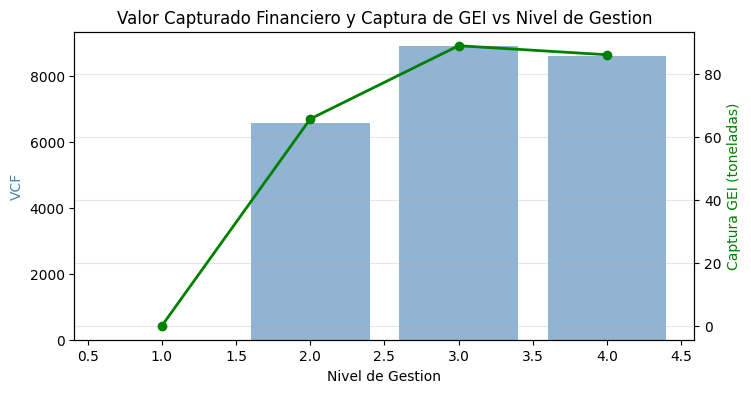

In [10]:
#Se evalua el VCF y la captura de GEI para cada nivel de gestion
resultados=[]
for n in range(1,5):
    ng2_n=nimp*n
    LDA_Gn=LDA*(nimp/ng2_n)
    nc_c1_gn=np.sum(df[LDA_Gn<LC1].iloc[:,0])
    nc_c3_gn=np.sum(df[LDA_Gn>OPVar].iloc[:,0])
    nc_c2_gn=np.sum(df.iloc[:,0])-nc_c1_gn-nc_c3_gn
    ncg_n=nc_c1_gn-nc_c1
    CGest_n=float(XGes.loc[XGes['Nivel']==n,'Costo (KUSD)'].values[0])
    VCapt_n=ncg_n*(PProm-CGest_n*n)
    TCaptGEI_n=VCapt_n/TGEI
    resultados.append([n,nc_c1_gn,nc_c2_gn,nc_c3_gn,ncg_n,CGest_n,VCapt_n,TCaptGEI_n])

dfs=pd.DataFrame(resultados,columns=['Nivel','C1','C2','C3','Migrados C2->C1','CGest (KUSD)','VCF','GEI (ton)'])
print(dfs.to_string(index=False))

#Grafica VCF y GEI por nivel
fig,ax1=plt.subplots(figsize=(8,4))
ax1.bar(dfs['Nivel'],dfs['VCF'],color='steelblue',alpha=0.6,label='VCF')
ax1.set_xlabel('Nivel de Gestion')
ax1.set_ylabel('VCF',color='steelblue')
ax2=ax1.twinx()
ax2.plot(dfs['Nivel'],dfs['GEI (ton)'],color='green',marker='o',linewidth=2,label='GEI capturado')
ax2.set_ylabel('Captura GEI (toneladas)',color='green')
plt.title('Valor Capturado Financiero y Captura de GEI vs Nivel de Gestion')
plt.grid(alpha=0.3)
plt.show()

**Analisis Final**

**1. Distribucion de perdidas (LDA)**: la curva LDA tiene una cola pesada hacia la derecha, lo que es tipico del riesgo operacional - hay muchos eventos pequenos y pocos eventos grandes. De las 3,332 transacciones fallidas que se analizaron:
*   El 58.6% (1,952 eventos) caen en C1 - son perdidas esperadas (con LDA menor a 9.45 M USD)
*   El 41.1% (1,370 eventos) caen en C2 - son perdidas gestionables (entre 9.45 y 102.90 M USD)
*   El 0.3% (10 eventos) caen en C3 - son perdidas catastroficas (con LDA mayor al OpVaR 99.9% = 102.90 M USD)

Esto confirma que la mayoria de las fallas son de bajo impacto y se pueden gestionar, mientras que los pocos eventos extremos son los que concentran el mayor riesgo financiero.

**2. LDA Gestionada (curva verde)**: cuando se aplica la gestion nivel 2, la curva verde se mueve hacia la izquierda comparada con la roja. 700 transacciones se mueven de C2 hacia C1 y los 10 eventos catastroficos de C3 desaparecen por completo, lo que demuestra que la gestion si esta funcionando para reducir las perdidas.

**3. Comparacion de metricas estadisticas**:
*   Promedio simple `ps` = 4.13 M USD (es el promedio sin tener en cuenta cuantas veces ocurre cada falla)
*   Promedio ponderado `pp` = 2.24 M USD (al considerar la frecuencia, el valor baja porque hay pocos eventos muy costosos y muchos eventos baratos)
*   Perdida ponderada con impacto `pnr` = 2.92 M USD (la matriz MI le da mas peso a las celdas mas criticas, por eso sube)
*   Perdida ponderada con gestion `png` = 1.08 M USD (al aplicar la gestion, el costo promedio por falla baja un 63% comparado con `pnr`)

**4. Analisis prospectivo - Nivel optimo de gestion**: la tabla de sensibilidad muestra que el VCF NO crece de manera lineal con el nivel de gestion. Hay un punto donde se maximiza:

| Nivel | Migrados | CGest | VCF | GEI (ton) |
|-------|----------|-------|-------|-----------|
| 1 | 0 | 0.012 | 0.00 | 0.00 |
| 2 | 700 | 0.037 | 6,563.37 | 65.63 |
| **3** | **995** | **0.173** | **8,887.25** | **88.87** |
| 4 | 1,100 | 0.408 | 8,601.06 | 86.01 |

El **Nivel de Gestion 3 (Moderado) maximiza el VCF en 8,887.25** y la captura de GEI en 88.87 toneladas. Aunque en el nivel 4 migran 105 eventos mas, el costo se duplica y el VCF baja - es el efecto de los rendimientos marginales decrecientes (a partir de cierto punto, invertir mas en gestion ya no es rentable).

**5. Captura equivalente de GEI**: el VCF optimo (8,887.25) al dividirlo por TGEI = 100 USD/tCO2eq (precio de referencia tomado del ejemplo de la clase) equivale a **88.87 toneladas de CO2 capturadas**.

**Recomendacion**: la entidad FINTECH deberia escoger el **Nivel 3 de gestion (Moderado)** como su punto optimo en la estrategia de gestion de riesgos. Con este nivel se logra:
*   Mover el 72.6% de los eventos C2 hacia C1 (995 de 1,370)
*   Eliminar por completo los eventos catastroficos C3
*   Generar un VCF de 8,887.25 - el maximo posible
*   Capturar 88.87 toneladas de CO2eq.
*   Mantener un costo razonable de 0.173 KUSD por evento, con la mejor relacion costo-beneficio

La gestion prospectiva de las fallas tecnologicas no solo reduce el costo promedio por falla en un 63% (pasando de 2.92 a 1.08 M USD por evento), sino que ademas convierte esa mejora operativa en un beneficio ambiental medible, conectando la estrategia financiera de la FINTECH con sus compromisos de sostenibilidad.